In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import os
import numpy as np

# Librerías para la técnica novedosa (Wavelets + PCA) y los modelos de AA/RN
# Si no está instalado pywt, correr antes: !pip install PyWavelets
import pywt
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score

#https://data.mendeley.com/datasets/543xpjycj9/1


def get_signal(file_path):
  """
  Extrae el archivo que esté en la ruta
  """
  try:
      df_signal = pd.read_csv(file_path, sep=r'\s+', header=None)
      signal_array = pd.to_numeric(df_signal.iloc[0], errors='coerce').dropna().to_numpy()

      if len(signal_array) == 0:
          print(f"Warning: No valid numeric data found in {file_path}. Returning None.")
          return None
      return signal_array.astype(float) # Ensure float dtype
  except FileNotFoundError:
      print(f"Error: File not found at {file_path}. Please check the path.")
      return None
  except Exception as e:
      print(f"An error occurred while loading the file: {e}")
      return None

import multiprocessing
import random

def get_signals(muscle='delt', condition='healthy', num_signals=-1):
    """
    Toma todas, o una cantidad específica de señales según el músculo y condición especificados.
    """
    root_dir = '//content/drive/MyDrive/Bio 4-1/PSIB/TPS/EMG Dataset Repository/'

    muscle_path = {
        'delt': '01_Deltoid/',
        'biceps': '02_Biceps_Brachii/'
    }[muscle]

    condition_path = {
        'healthy': 'Healthy/',
        'myopathy': 'Myopathy/',
        'neuropathy': 'Neuropathy/'
    }[condition]

    full_path_dir = os.path.join(root_dir, muscle_path, condition_path)

    # Lista de todos los archivos .asc
    all_files = [f for f in os.listdir(full_path_dir) if f.endswith('.asc')]
    all_files.sort()

    if num_signals == -1:
      files_to_process = all_files
    else:
      # Para probar el algoritmo con diferenctes grupos, se seleccionan señales aleatorias
      num_to_select = min(num_signals, len(all_files))
      files_to_process = random.sample(all_files, num_to_select)
      files_to_process.sort()

    print(f"Loading {len(files_to_process)} signals for {muscle} - {condition}...")

    file_paths = [os.path.join(full_path_dir, filename) for filename in files_to_process]

    # multiprocessing para acelerar el proceso
    with multiprocessing.Pool(processes=os.cpu_count()) as pool:
        all_signals = pool.map(get_signal, file_paths)

    # Se filtran lasa señales que resultaron en error de carga
    all_signals = [signal for signal in all_signals if signal is not None]

    print(f"Loaded {len(all_signals)} signals")

    return all_signals


raw_healthy = get_signal("/content/drive/MyDrive/Bio 4-1/PSIB/TPS/EMG Dataset Repository/01_Deltoid/Healthy/EMG _036 _18_ LD_Hea.asc")
raw_myopathy = get_signal("/content/drive/MyDrive/Bio 4-1/PSIB/TPS/EMG Dataset Repository/01_Deltoid/Myopathy/EMG _129 _28_ RD_Myo.asc")
raw_neuropathy = get_signal("/content/drive/MyDrive/Bio 4-1/PSIB/TPS/EMG Dataset Repository/01_Deltoid/Neuropathy/EMG _151 _01_ RD_Neu.asc")

--- Sujeto Sano ---
Umbral adaptativo calculado: 933.5608 mV
Se lograron aislar 83 MUAPs válidas.


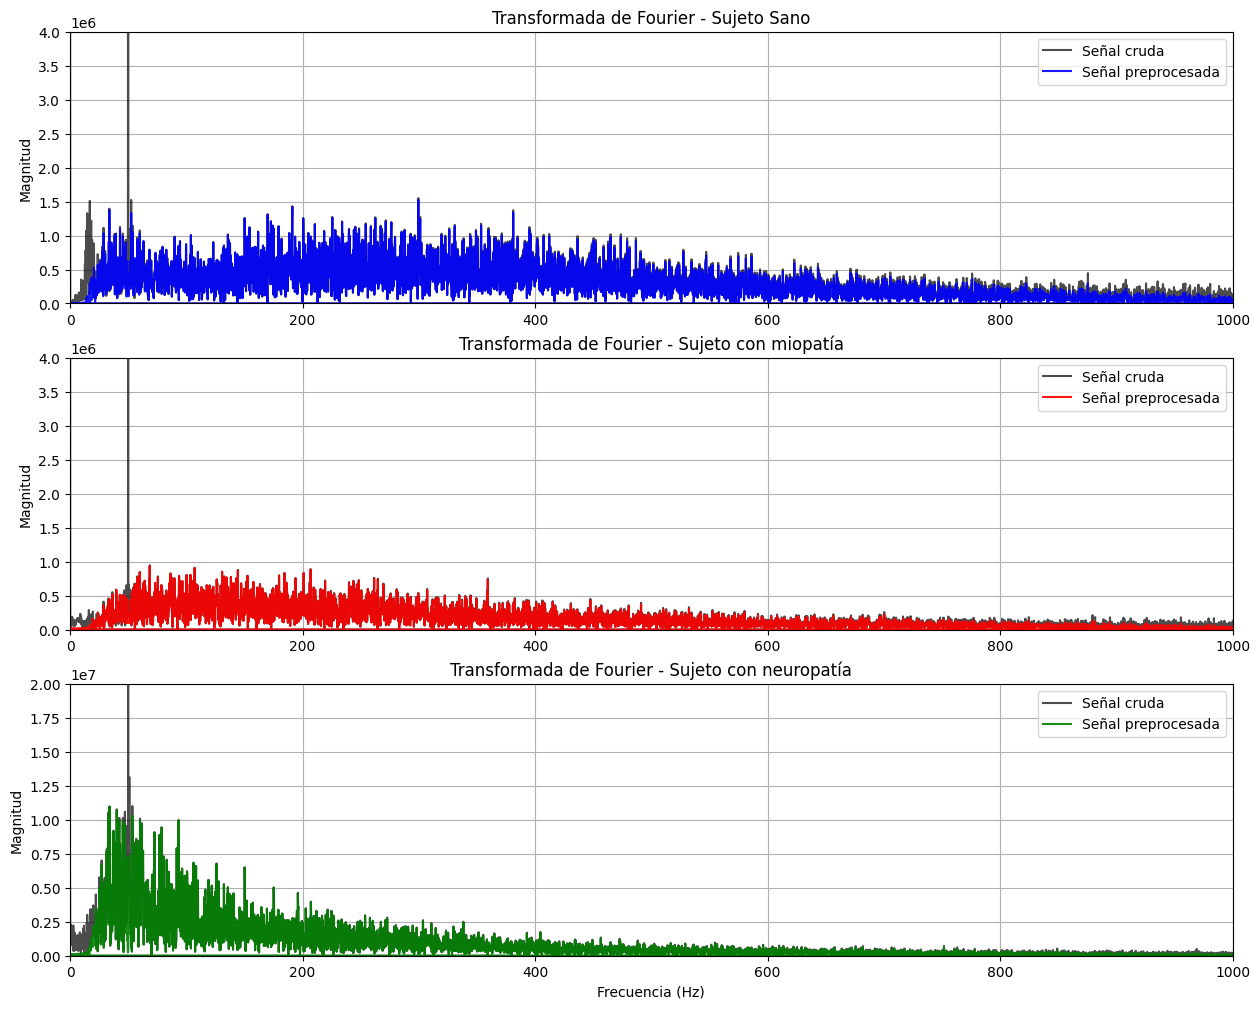

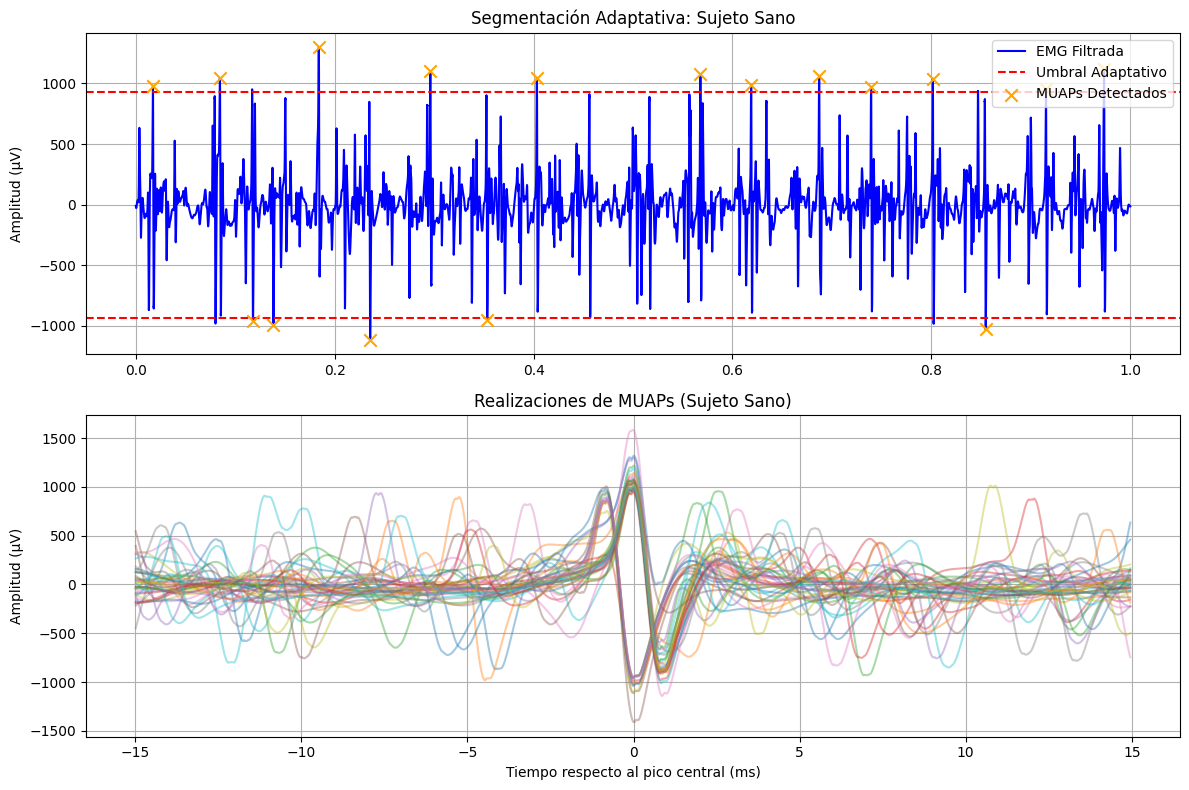

--- Miopatía ---
Umbral adaptativo calculado: 533.9035 mV
Se lograron aislar 22 MUAPs válidas.


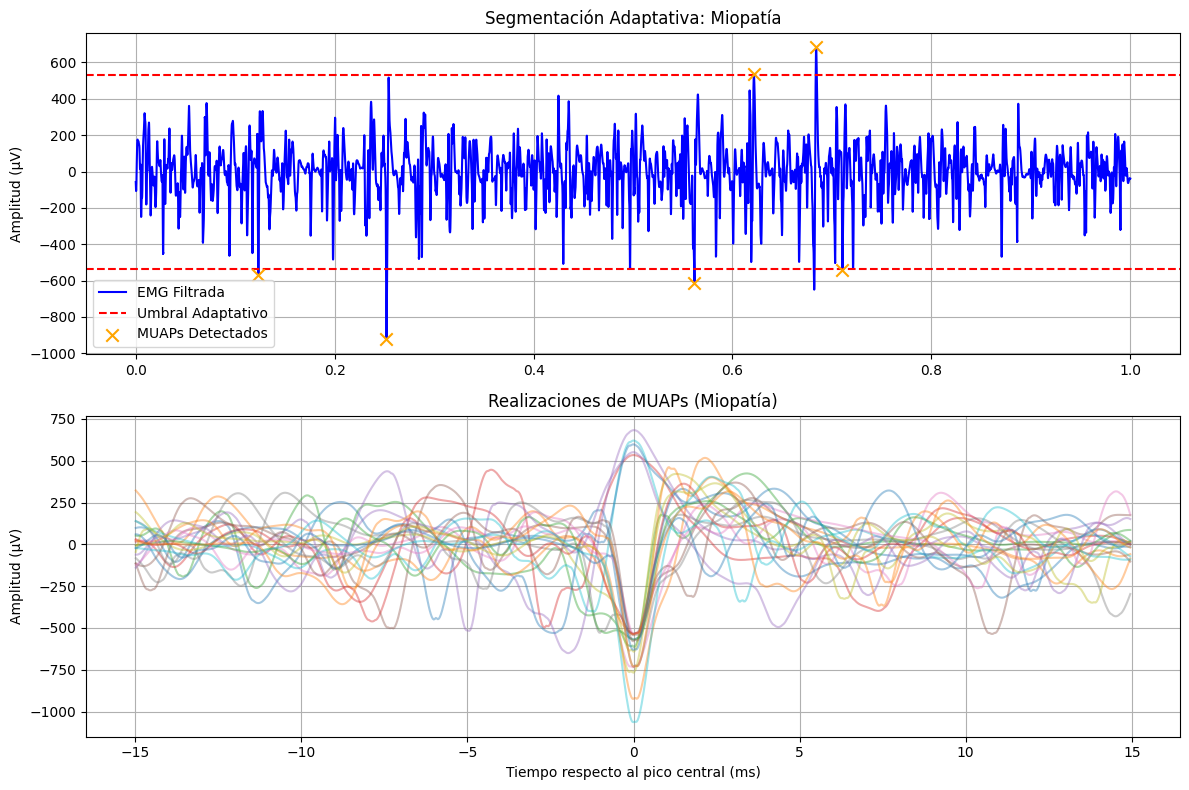

--- Neuropatía ---
Umbral adaptativo calculado: 3821.9842 mV
Se lograron aislar 20 MUAPs válidas.


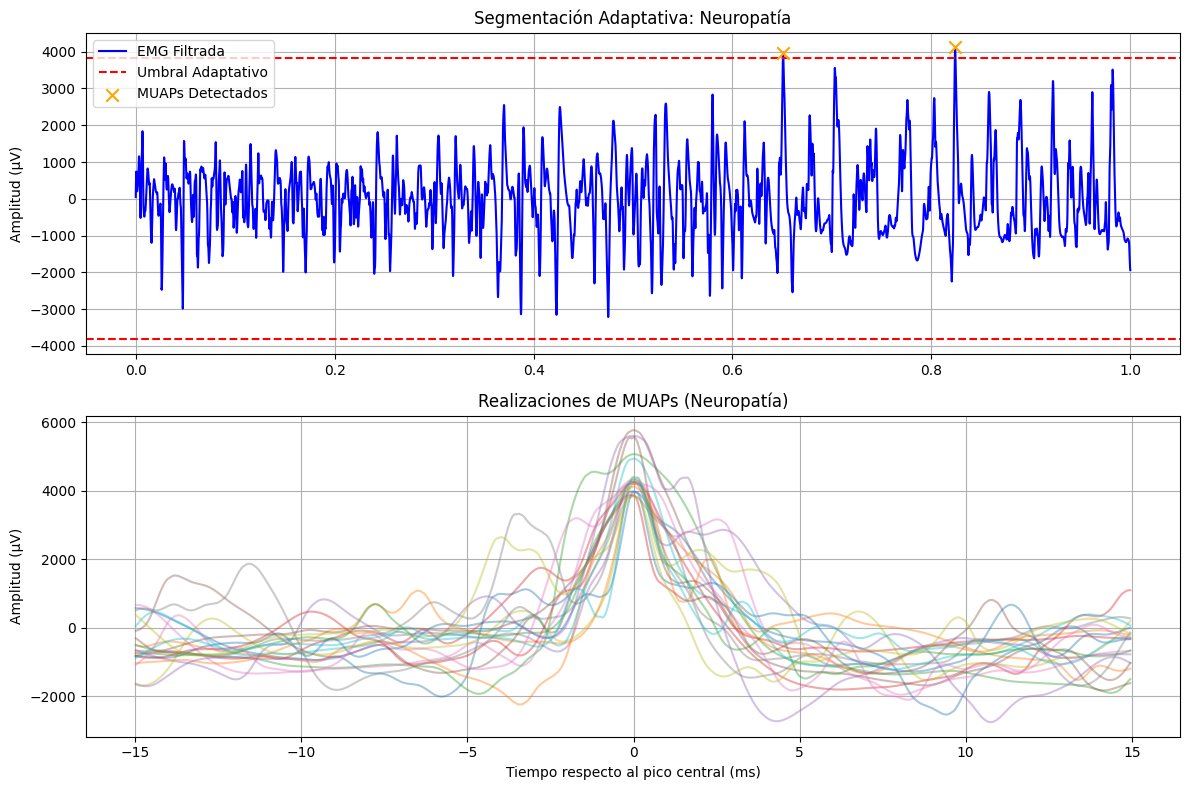


==== TABLA DE CARACTERÍSTICAS EXTRAÍDAS ====
                    Sujeto Sano (Media ± DE) Miopatía (Media ± DE)  \
Amplitud_uV               1947.303 ± 265.534     1031.660 ± 187.469   
Duracion_ms                    9.211 ± 4.152         15.166 ± 6.670   
Fases                          4.181 ± 1.363          4.864 ± 2.054   
Giros                          3.940 ± 1.282          4.818 ± 2.702   
AUC                            3.018 ± 1.058          2.749 ± 0.994   
Ratio_Amp_Dur               247.777 ± 96.906        84.404 ± 47.082   
Skewness                      -0.254 ± 0.613         -0.750 ± 0.777   
Kurtosis                       0.575 ± 0.972          0.852 ± 1.317   
Freq_Media_Hz               320.593 ± 43.953       217.876 ± 34.601   
Freq_Mediana_Hz             302.260 ± 78.824       176.303 ± 55.180   
Energia_Banda_Baja             0.244 ± 0.166          0.608 ± 0.131   
Energia_Banda_Media            0.620 ± 0.158          0.330 ± 0.124   
Energia_Banda_Alta           

In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np



fs = 32768

"""###Preprocesamiento"""

from scipy.signal import butter, filtfilt, iirnotch, wiener, freqz, find_peaks

def get_pp_filters(fs = 32768):
    """
    Devuelve los parámetros de filtro notch y pasa-banda
    """
    # Filtro Notch
    f0 = 50.0 #Frec a filtrar
    Q = 30.0 #Determina el ancho de banda (bw): Q = w0/bw
    b_notch, a_notch = iirnotch(f0, Q, fs)

    lowcut = 20.0
    highcut = 1000.0
    f_nyq = 0.5 * fs  # Frecuencia de Nyquist
    low = lowcut / f_nyq
    high = highcut / f_nyq

    b_band, a_band = butter(4, [low, high], btype="band")

    return (b_notch, a_notch), (b_band, a_band)

def preprocessing(raw, fs = 32768):
    """Aplica un filtro Notch (50Hz), un filtro Pasa-Banda (20-1000Hz)
    y un filtro óptivo de Wiener para remover ruido de amplificación.
    """

    (b_notch, a_notch), (b_band, a_band) = get_pp_filters(fs)

    # # Filtro Notch
    notch_sig = filtfilt(b_notch, a_notch, raw)
    # # Filtro Pasa-Banda
    filtered = filtfilt(b_band, a_band, notch_sig)

    #Filtro Óptimo de Wiener (Reducción adaptativa de ruido de fondo)
    pp_signal = wiener(filtered, mysize=15)

    return pp_signal

healthy = preprocessing(raw_healthy, fs)
myopathy = preprocessing(raw_myopathy, fs)
neuropathy = preprocessing(raw_neuropathy, fs)

"""###Comparación en frecuencia de datos crudos y preprocesados"""

N_healthy = len(healthy)
N_myopathy = len(myopathy)
N_neuropathy = len(neuropathy)

Y_healthy = np.fft.fft(healthy)
Y_myopathy = np.fft.fft(myopathy)
Y_neuropathy = np.fft.fft(neuropathy)

freq_healthy = np.fft.fftfreq(N_healthy, 1/fs)
freq_myopathy = np.fft.fftfreq(N_myopathy, 1/fs)
freq_neuropathy = np.fft.fftfreq(N_neuropathy, 1/fs)

N_raw_healthy = len(raw_healthy)
N_raw_myopathy = len(raw_myopathy)
N_raw_neuropathy = len(raw_neuropathy)

Y_raw_healthy = np.fft.fft(raw_healthy)
Y_raw_myopathy = np.fft.fft(raw_myopathy)
Y_raw_neuropathy = np.fft.fft(raw_neuropathy)

freq_raw_healthy = np.fft.fftfreq(N_raw_healthy, 1/fs)
freq_raw_myopathy = np.fft.fftfreq(N_raw_myopathy, 1/fs)
freq_raw_neuropathy = np.fft.fftfreq(N_raw_neuropathy, 1/fs)

plt.figure(figsize=(15, 12))

plt.subplot(3, 1, 1)
plt.plot(freq_raw_healthy, np.abs(Y_raw_healthy), color='black', alpha=0.7, label='Señal cruda')
plt.plot(freq_healthy, np.abs(Y_healthy), color='blue', alpha=0.9, label='Señal preprocesada')
plt.title('Transformada de Fourier - Sujeto Sano')
plt.ylabel('Magnitud')
plt.ylim(0, 4e6)
plt.xlim(0, 1000)
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(freq_raw_myopathy, np.abs(Y_raw_myopathy), color='black', alpha=0.7, label='Señal cruda')
plt.plot(freq_myopathy, np.abs(Y_myopathy), color='red', alpha=0.9, label='Señal preprocesada')
plt.title('Transformada de Fourier - Sujeto con miopatía')
plt.ylabel('Magnitud')
plt.ylim(0, .4e7)
plt.xlim(0, 1000)
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(freq_raw_neuropathy, np.abs(Y_raw_neuropathy), color='black', alpha=0.7, label='Señal cruda')
plt.plot(freq_neuropathy, np.abs(Y_neuropathy), color='green', alpha=0.9, label='Señal preprocesada')
plt.title('Transformada de Fourier - Sujeto con neuropatía')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Magnitud')
plt.ylim(0, 2e7)
plt.xlim(0, 1000)
plt.legend()
plt.grid(True)

"""
###Segmentación de MUAPs
"""

def segmentar_muaps(señal_limpia, fs, k=4, ventana_ms=30.0):
    """Detecta picos basados en un umbral adaptativo (k * STD) y extrae
    ventanas de cada MUAP alineadas por su pico máximo.
    """
    std_señal = np.std(señal_limpia)
    umbral_positivo = k * std_señal

    distancia_min_muestras = int(0.015 * fs)

    picos_indices, _ = find_peaks(
        np.abs(señal_limpia), height=umbral_positivo, distance=distancia_min_muestras
    )

    ancho_ventana = int((ventana_ms / 1000.0) * fs)
    mitad_ventana = ancho_ventana // 2

    realizaciones = []
    indices_validos = []

    for pico in picos_indices:
        if pico - mitad_ventana >= 0 and pico + mitad_ventana < len(señal_limpia):
            fragmento = señal_limpia[pico - mitad_ventana : pico + mitad_ventana]
            pico_local = np.argmax(np.abs(fragmento))
            desplazamiento = pico_local - mitad_ventana
            nuevo_pico = pico + desplazamiento

            if nuevo_pico - mitad_ventana >= 0 and nuevo_pico + mitad_ventana < len(señal_limpia):
                ventana_alineada = señal_limpia[nuevo_pico - mitad_ventana : nuevo_pico + mitad_ventana]
                realizaciones.append(ventana_alineada)
                indices_validos.append(nuevo_pico)

    return np.array(realizaciones), np.array(indices_validos), umbral_positivo, std_señal

def plotear_muaps(señal, fs, titulo_señal="EMG"):
    muaps, indices_picos, umbral, desv_std = segmentar_muaps(señal, fs, k=4, ventana_ms=30.0)

    print(f"--- {titulo_señal} ---")
    print(f"Umbral adaptativo calculado: {umbral:.4f} mV")
    print(f"Se lograron aislar {muaps.shape[0]} MUAPs válidas.")

    muestras_visualizar = int(1 * fs)
    tiempo_continuo = np.arange(muestras_visualizar) / fs

    plt.figure(figsize=(12, 8))

    plt.subplot(2, 1, 1)
    plt.plot(tiempo_continuo, señal[:muestras_visualizar], color="blue", label="EMG Filtrada")
    plt.axhline(umbral, color="red", linestyle="--", label=f"Umbral Adaptativo")
    plt.axhline(-umbral, color="red", linestyle="--")

    picos_en_seccion = indices_picos[indices_picos < muestras_visualizar]
    plt.scatter(
        picos_en_seccion / fs,
        señal[picos_en_seccion],
        color="orange",
        marker="x",
        s=80,
        zorder=3,
        label="MUAPs Detectados",
    )

    plt.title(f"Segmentación Adaptativa: {titulo_señal}")
    plt.ylabel("Amplitud (µV)")
    plt.legend()
    plt.grid(True)

    if len(muaps) > 0:
        tiempo_ventana = (np.arange(muaps.shape[1]) - (muaps.shape[1] // 2)) / (fs / 1000.0)
        plt.subplot(2, 1, 2)
        for i in range(min(40, len(muaps))):
            plt.plot(tiempo_ventana, muaps[i], alpha=0.4)

        plt.title(f"Realizaciones de MUAPs ({titulo_señal})")
        plt.xlabel("Tiempo respecto al pico central (ms)")
        plt.ylabel("Amplitud (µV)")
        plt.grid(True)

    plt.tight_layout()
    plt.show()

    return muaps, indices_picos, umbral, desv_std

muaps_sano, indices_sano, umbral_sano, desv_std_sano = plotear_muaps(healthy, fs, "Sujeto Sano")
muaps_mio, indices_mio, umbral_mio, desv_std_mio = plotear_muaps(myopathy, fs, "Miopatía")
muaps_neuro, indices_neuro, umbral_neuro, desv_std_neuro = plotear_muaps(neuropathy, fs, "Neuropatía")

"""###Extracción de características"""

def calcular_fases(muap_util, sigma_ruido):
    """
    Calcula las fases usando ÚNICAMENTE el segmento recortado del MUAP.
    Cada fase debe alcanzar un pico mínimo para ser validada y evitar el ruido.
    """
    if len(muap_util) < 2:
        return 1

    # Umbral de seguridad para validar la fase
    umbral_fase = 1.5 * sigma_ruido

    fases = 1
    signo_actual = np.sign(muap_util[0])
    pico_max_fase = abs(muap_util[0])

    for valor in muap_util:
        signo_nuevo = np.sign(valor)
        if signo_nuevo == 0:
            continue  # Ignorar ceros exactos para evitar ambigüedades

        # Se registra el pico más alto alcanzado dentro de la fase actual
        if abs(valor) > pico_max_fase:
            pico_max_fase = abs(valor)

        # Si hay un cambio de signo...
        if signo_nuevo != signo_actual:
            # se evalúa si la fase que acaba de terminar tuvo la energía suficiente
            if pico_max_fase >= umbral_fase:
                fases += 1
                signo_actual = signo_nuevo
                pico_max_fase = abs(valor)  # Reiniciar para la nueva fase
            else:
                # Si fue una oscilación chica por ruido, no se cuenta como nueva fase
                pass

    return fases

def calcular_giros(muap_util, sigma_ruido):
    """Calcula los giros (cambios de dirección de pendiente) en el segmento útil.
    Un giro es válido si la diferencia de voltaje con el giro anterior
    supera un umbral mínimo significativo.
    """
    if len(muap_util) < 3:
        return 0

    # Umbral clínico típico de giros (30 uV o adaptativo según el ruido)
    umbral_giro = max(30, 2.0 * sigma_ruido)

    giros = 0
    ultimo_extremo = muap_util[0]
    pendiente_actual = 0  # 1: subiendo, -1: bajando

    for i in range(1, len(muap_util)):
        diff = muap_util[i] - muap_util[i - 1]
        if diff == 0:
            continue

        pendiente_nueva = 1 if diff > 0 else -1

        if pendiente_actual == 0:
            pendiente_actual = pendiente_nueva
            continue

        # Si la pendiente cambia de dirección, se detecta un posible pico/valle
        if pendiente_nueva != pendiente_actual:
            val_extremo = muap_util[i - 1]

            # validación si la altura del giro es significativa
            if abs(val_extremo - ultimo_extremo) >= umbral_giro:
                giros += 1
                ultimo_extremo = val_extremo

            pendiente_actual = pendiente_nueva

    return giros

def calcular_duracion(muap, fs, sigma_ruido):
    """Calcula la duración generando una envoltura de energía de 1.5 ms

    y aplicando un umbral basal más sensible.
    """
    # Ventana de suavizado: 1.5 milisegundos
    # une los cruces por cero y genera una loma continua
    ancho_envoltura = int(0.0015 * fs)
    if ancho_envoltura % 2 == 0:
        ancho_envoltura += 1  #Si las muestras son pares, agrega una para tener centro

    # Se genera la envoltura absoluta
    envoltura = np.convolve(
        np.abs(muap), np.ones(ancho_envoltura) / ancho_envoltura, mode="same"
    ) #Filtro de media móvil con valores absolutos para generar envoltura

    # Umbral basal más sensible (0.4 * sigma) para pescar el inicio real.
    # Además se coloca un piso mínimo de seguridad de 20 uV
    umbral = max(20, 0.4 * sigma_ruido)

    centro = len(muap) // 2

    # Ventana de permanencia de 0.8 ms, busca desde el centro hasta los bordes cuando la función permanece por 8ms por debajo del umbral
    muestras_permanencia = int(0.0008 * fs)

    # Buscar inicio de MUAP hacia la izquierda
    inicio = 0
    for i in range(centro, muestras_permanencia, -1):
        if np.all(envoltura[i - muestras_permanencia : i] < umbral):
            inicio = i
            break

    # Buscar fin de MUAP hacia la derecha
    fin = len(muap) - 1
    for i in range(centro, len(muap) - muestras_permanencia):
        if np.all(envoltura[i : i + muestras_permanencia] < umbral):
            fin = i
            break

    # Conversión a milisegundos
    duracion_ms = ((fin - inicio) / fs) * 1000.0
    return duracion_ms, inicio, fin

"""### Features nuevas para el final: forma de onda, espectrales y Wavelet (técnica novedosa)

La devolución del TPS pidió explícitamente ampliar el número de métricas para poder
entrenar un modelo de ML, e incorporar features espectrales. Se agregan acá:

1. Features de forma de onda (dominio temporal): área bajo la curva rectificada,
   relación amplitud/duración, asimetría (skewness) y curtosis.
2. Features espectrales (FFT): frecuencia media, frecuencia mediana y energía
   relativa en 3 bandas (baja/media/alta) dentro del ancho de banda del MUAP.
3. Features de Wavelet (técnica novedosa, Sección "Desarrollo" del final):
   energía relativa por nivel de descomposición (Wavelet Discreta, db4) y
   entropía de Shannon de esa distribución de energía, que resume qué tan
   concentrada o dispersa está la energía del MUAP en distintas escalas
   tiempo-frecuencia (esperable que varíe entre sano/miopatía/neuropatía).
"""

def calcular_features_forma(muap_util, amp_p2p, dur_ms, fs):
    """Features adicionales de forma de onda en el dominio temporal."""
    # Área bajo la curva rectificada (aprox. por suma de Riemann, evita
    # depender de np.trapz/np.trapezoid que cambian de nombre entre versiones)
    auc = np.sum(np.abs(muap_util)) / fs

    # Relación amplitud/duración: "densidad" del potencial
    ratio_amp_dur = amp_p2p / dur_ms if dur_ms > 0 else 0.0

    # Asimetría y curtosis de la forma de onda
    if len(muap_util) > 2 and np.std(muap_util) > 0:
        asimetria = skew(muap_util)
        curt = kurtosis(muap_util)
    else:
        asimetria, curt = 0.0, 0.0

    return auc, ratio_amp_dur, asimetria, curt


def calcular_features_espectrales(muap_util, fs):
    """Frecuencia media, frecuencia mediana y energía relativa por banda
    (baja/media/alta) del espectro del MUAP.
    """
    n = len(muap_util)
    if n < 4:
        return 0.0, 0.0, 0.0, 0.0, 0.0

    espectro = np.abs(np.fft.rfft(muap_util))
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    energia_total = np.sum(espectro ** 2)

    if energia_total == 0:
        return 0.0, 0.0, 0.0, 0.0, 0.0

    # Frecuencia media (centroide espectral)
    freq_media = np.sum(freqs * espectro ** 2) / energia_total

    # Frecuencia mediana (frecuencia que divide la energía del espectro a la mitad)
    energia_acum = np.cumsum(espectro ** 2)
    idx_mediana = np.searchsorted(energia_acum, energia_total / 2.0)
    freq_mediana = freqs[min(idx_mediana, len(freqs) - 1)]

    # Energía relativa por banda (bandas típicas dentro del ancho de banda del MUAP)
    banda_baja = (freqs >= 0) & (freqs < 200)
    banda_media = (freqs >= 200) & (freqs < 500)
    banda_alta = (freqs >= 500)

    energia_baja = np.sum(espectro[banda_baja] ** 2) / energia_total
    energia_media = np.sum(espectro[banda_media] ** 2) / energia_total
    energia_alta = np.sum(espectro[banda_alta] ** 2) / energia_total

    return freq_media, freq_mediana, energia_baja, energia_media, energia_alta


def calcular_features_wavelet(muap_util, wavelet="db4", nivel=4):
    """Descompone el MUAP con Wavelet Discreta (DWT) y devuelve la energía
    relativa de cada nivel de detalle/aproximación más la entropía de Shannon
    de esa distribución (técnica novedosa pedida por la consigna del final).
    """
    n = len(muap_util)
    nivel_max = pywt.dwt_max_level(n, pywt.Wavelet(wavelet).dec_len)
    nivel_usado = min(nivel, nivel_max) if nivel_max > 0 else 0

    if nivel_usado < 1:
        return [0.0] * (nivel + 1) + [0.0]

    coeffs = pywt.wavedec(muap_util, wavelet, level=nivel_usado)
    energias = np.array([np.sum(c ** 2) for c in coeffs])
    energia_total = np.sum(energias)

    if energia_total == 0:
        return [0.0] * (nivel + 1) + [0.0]

    energias_rel = energias / energia_total

    # Completar con ceros si la señal es muy corta para llegar al nivel pedido
    if len(energias_rel) < nivel + 1:
        energias_rel = np.concatenate([energias_rel, np.zeros(nivel + 1 - len(energias_rel))])
    else:
        energias_rel = energias_rel[: nivel + 1]

    p = energias_rel[energias_rel > 0]
    entropia = -np.sum(p * np.log2(p)) if len(p) > 0 else 0.0

    return list(energias_rel) + [entropia]


def extraer_metricas_dataset(matriz_realizaciones, fs, desv_std, musculo=None, condicion=None):
    """Itera sobre todas las realizaciones segmentadas para construir
    un DataFrame con las características extraídas: las 4 originales
    (duración, amplitud, fases, giros) más las nuevas features de forma,
    espectrales y de Wavelet pedidas para el final. Si se pasan `musculo`
    y `condicion`, se agregan como columnas de etiqueta para poder armar
    después el dataset consolidado de entrenamiento de los modelos de ML/RN.
    """
    caracteristicas = {
        "Amplitud_uV": [], "Duracion_ms": [], "Fases": [], "Giros": [],
        "AUC": [], "Ratio_Amp_Dur": [], "Skewness": [], "Kurtosis": [],
        "Freq_Media_Hz": [], "Freq_Mediana_Hz": [],
        "Energia_Banda_Baja": [], "Energia_Banda_Media": [], "Energia_Banda_Alta": [],
        "Wavelet_E0": [], "Wavelet_E1": [], "Wavelet_E2": [], "Wavelet_E3": [], "Wavelet_E4": [],
        "Wavelet_Entropia": [],
    }

    for muap in matriz_realizaciones:

        # Duración
        dur, inicio, fin = calcular_duracion(muap, fs, desv_std)

        muap_util = muap[inicio: fin + 1]

        # Amplitud Pico a Pico
        amp_p2p = np.max(muap_util) - np.min(muap_util)

        # Fases
        fas = calcular_fases(muap_util, desv_std)

        # Giros
        gir = calcular_giros(muap_util, desv_std)

        # Features de forma (nuevas)
        auc, ratio_amp_dur, asimetria, curt = calcular_features_forma(muap_util, amp_p2p, dur, fs)

        # Features espectrales (nuevas)
        freq_media, freq_mediana, e_baja, e_media, e_alta = calcular_features_espectrales(muap_util, fs)

        # Features de Wavelet (técnica novedosa)
        wav_feats = calcular_features_wavelet(muap_util, wavelet="db4", nivel=4)

        # Almacenamiento
        caracteristicas["Amplitud_uV"].append(amp_p2p)
        caracteristicas["Duracion_ms"].append(dur)
        caracteristicas["Fases"].append(fas)
        caracteristicas["Giros"].append(gir)
        caracteristicas["AUC"].append(auc)
        caracteristicas["Ratio_Amp_Dur"].append(ratio_amp_dur)
        caracteristicas["Skewness"].append(asimetria)
        caracteristicas["Kurtosis"].append(curt)
        caracteristicas["Freq_Media_Hz"].append(freq_media)
        caracteristicas["Freq_Mediana_Hz"].append(freq_mediana)
        caracteristicas["Energia_Banda_Baja"].append(e_baja)
        caracteristicas["Energia_Banda_Media"].append(e_media)
        caracteristicas["Energia_Banda_Alta"].append(e_alta)
        caracteristicas["Wavelet_E0"].append(wav_feats[0])
        caracteristicas["Wavelet_E1"].append(wav_feats[1])
        caracteristicas["Wavelet_E2"].append(wav_feats[2])
        caracteristicas["Wavelet_E3"].append(wav_feats[3])
        caracteristicas["Wavelet_E4"].append(wav_feats[4])
        caracteristicas["Wavelet_Entropia"].append(wav_feats[5])

    df = pd.DataFrame(caracteristicas)

    if musculo is not None:
        df["Musculo"] = musculo
    if condicion is not None:
        df["Condicion"] = condicion

    return df

df_miopatia = extraer_metricas_dataset(muaps_mio, fs, desv_std_mio, musculo="deltoides", condicion="miopatia")
df_neuropatia = extraer_metricas_dataset(muaps_neuro, fs, desv_std_neuro, musculo="deltoides", condicion="neuropatia")
df_sano = extraer_metricas_dataset(muaps_sano, fs, desv_std_sano, musculo="deltoides", condicion="sano")

# Se calcula la media y desviación estándar de cada grupo para el informe
resumen_miopatia = df_miopatia.drop(columns=["Musculo", "Condicion"]).agg(["mean", "std"]).T
resumen_neuropatia = df_neuropatia.drop(columns=["Musculo", "Condicion"]).agg(["mean", "std"]).T
resumen_sano = df_sano.drop(columns=["Musculo", "Condicion"]).agg(["mean", "std"]).T

# Se guardan los resultados en una única tabla comparativa descriptiva
tabla_comparativa = pd.DataFrame(
    {
        "Sujeto Sano (Media ± DE)": resumen_sano.apply(
            lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1
        ),
        "Miopatía (Media ± DE)": resumen_miopatia.apply(
            lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1
        ),
        "Neuropatía (Media ± DE)": resumen_neuropatia.apply(
            lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1
        ),
    }
)

print("\n==== TABLA DE CARACTERÍSTICAS EXTRAÍDAS ====")
print(tabla_comparativa)




In [ ]:
"""### Carga de múltiples señales del deloides"""

# all_raw_healthy_delt = get_signals(muscle='delt', condition='healthy', num_signals=10)
# all_raw_myopathy_delt = get_signals(muscle='delt', condition='myopathy', num_signals=10)
# all_raw_neuropathy_delt = get_signals(muscle='delt', condition='neuropathy', num_signals=10)
all_raw_healthy_delt = get_signals(muscle='delt', condition='healthy')
all_raw_myopathy_delt = get_signals(muscle='delt', condition='myopathy')
all_raw_neuropathy_delt = get_signals(muscle='delt', condition='neuropathy')

"""### Carga de múltiples señales del bíceps"""

# all_raw_healthy_biceps = get_signals(muscle='biceps', condition='healthy', num_signals=10)
# all_raw_myopathy_biceps = get_signals(muscle='biceps', condition='myopathy', num_signals=10)
# all_raw_neuropathy_biceps = get_signals(muscle='biceps', condition='neuropathy', num_signals=10)
all_raw_healthy_biceps = get_signals(muscle='biceps', condition='healthy')
all_raw_myopathy_biceps = get_signals(muscle='biceps', condition='myopathy')
all_raw_neuropathy_biceps = get_signals(muscle='biceps', condition='neuropathy')

"""###Preprocesamiento de arrays de señales"""

all_pp_healthy_delt = [preprocessing(signal) for signal in all_raw_healthy_delt]
all_pp_myopathy_delt = [preprocessing(signal) for signal in all_raw_myopathy_delt]
all_pp_neuropathy_delt = [preprocessing(signal) for signal in all_raw_neuropathy_delt]

all_pp_healthy_biceps = [preprocessing(signal) for signal in all_raw_healthy_biceps]
all_pp_myopathy_biceps = [preprocessing(signal) for signal in all_raw_myopathy_biceps]
all_pp_neuropathy_biceps = [preprocessing(signal) for signal in all_raw_neuropathy_biceps]


Loading 100 signals for delt - healthy...
Loaded 100 signals
Loading 50 signals for delt - myopathy...
Loaded 50 signals
Loading 50 signals for delt - neuropathy...
Loaded 50 signals
Loading 100 signals for biceps - healthy...
Loaded 100 signals
Loading 50 signals for biceps - myopathy...
Loaded 50 signals
Loading 50 signals for biceps - neuropathy...
Loaded 50 signals


Segmented 3011 MUAPs from all healthy deltoid signals.
Segmented 1643 MUAPs from all myopathy deltoid signals.
Segmented 1426 MUAPs from all neuropathy deltoid signals.
Segmented 3882 MUAPs from all healthy biceps signals.
Segmented 1509 MUAPs from all myopathy biceps signals.
Segmented 1880 MUAPs from all neuropathy biceps signals.

==== TABLA DE CARACTERÍSTICAS EXTRAÍDAS PARA TODOS LOS SEÑALES DE DELTOIDES ====


,Sujeto Sano (Media ± DE),Miopatía (Media ± DE),Neuropatía (Media ± DE)
Amplitud_uV,1657.720 ± 759.005,1470.280 ± 1167.067,4265.551 ± 1931.265
Duracion_ms,12.071 ± 6.705,12.105 ± 8.536,12.838 ± 6.844
Fases,4.238 ± 2.137,4.505 ± 3.078,3.853 ± 1.768
Giros,3.760 ± 2.426,4.184 ± 3.598,3.535 ± 1.913
AUC,4.042 ± 3.014,3.773 ± 3.926,10.936 ± 8.070
Ratio_Amp_Dur,164.910 ± 80.097,123.663 ± 89.666,402.681 ± 237.394
Skewness,-0.402 ± 0.900,-0.282 ± 0.970,-0.041 ± 1.158
Kurtosis,0.507 ± 1.361,0.853 ± 1.801,0.861 ± 1.679
Freq_Media_Hz,223.813 ± 75.470,217.362 ± 108.824,204.040 ± 90.878
Freq_Mediana_Hz,189.311 ± 98.297,179.514 ± 113.381,169.967 ± 104.849



==== TABLA DE CARACTERÍSTICAS EXTRAÍDAS PARA TODOS LOS SEÑALES DE BÍCEPS ====


,Sujeto Sano (Media ± DE),Miopatía (Media ± DE),Neuropatía (Media ± DE)
Amplitud_uV,782.467 ± 388.060,1666.806 ± 942.381,3268.603 ± 1964.340
Duracion_ms,12.213 ± 7.359,13.582 ± 7.582,11.361 ± 6.870
Fases,4.073 ± 2.231,4.638 ± 2.795,3.465 ± 1.916
Giros,3.641 ± 2.623,4.353 ± 3.526,3.001 ± 2.218
AUC,1.961 ± 1.701,4.468 ± 3.928,7.742 ± 6.647
Ratio_Amp_Dur,76.832 ± 40.892,143.345 ± 83.626,335.359 ± 190.677
Skewness,-0.567 ± 1.010,-0.585 ± 1.014,-0.209 ± 1.225
Kurtosis,0.855 ± 1.783,0.982 ± 2.132,0.887 ± 2.048
Freq_Media_Hz,217.153 ± 72.439,221.138 ± 81.480,190.777 ± 82.390
Freq_Mediana_Hz,174.933 ± 90.551,181.643 ± 99.222,149.127 ± 95.329



Dataset consolidado: 13351 MUAPs, 21 columnas
Condicion
sano          6893
neuropatia    3306
miopatia      3152
Name: count, dtype: int64

Varianza explicada por las 2 primeras componentes: 31.4% + 18.9% = 50.3%


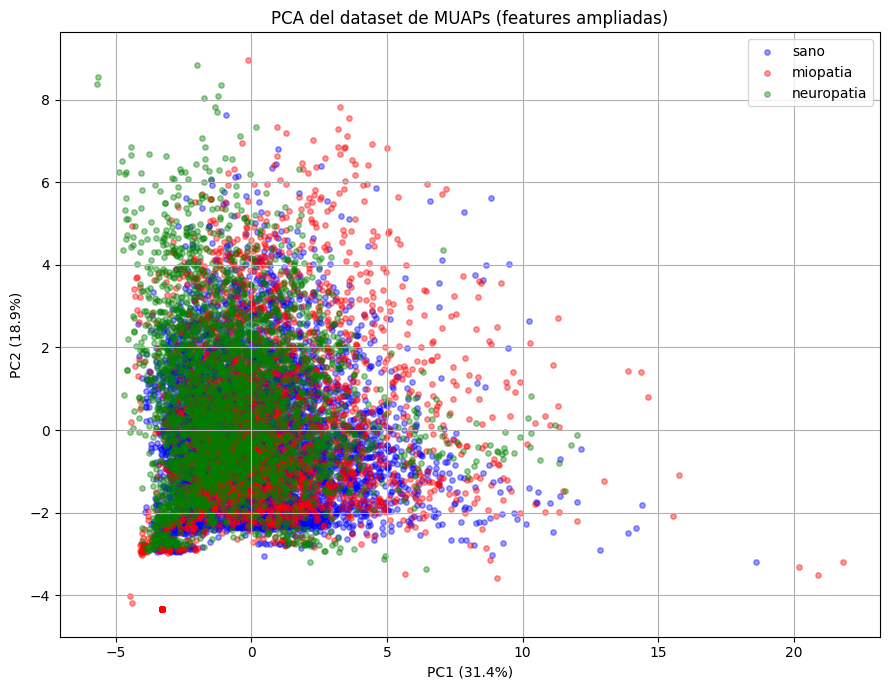


Entrenamiento: 10680 MUAPs | Prueba: 2671 MUAPs

==== RESULTADOS - RANDOM FOREST ====
Accuracy: 0.808 | F1-macro: 0.776
              precision    recall  f1-score   support

    miopatia       0.74      0.46      0.57       631
  neuropatia       0.89      0.94      0.92       661
        sano       0.79      0.91      0.84      1379

    accuracy                           0.81      2671
   macro avg       0.81      0.77      0.78      2671
weighted avg       0.80      0.81      0.80      2671



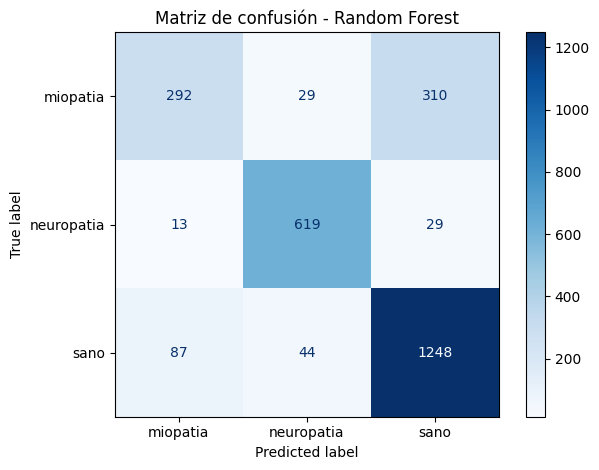

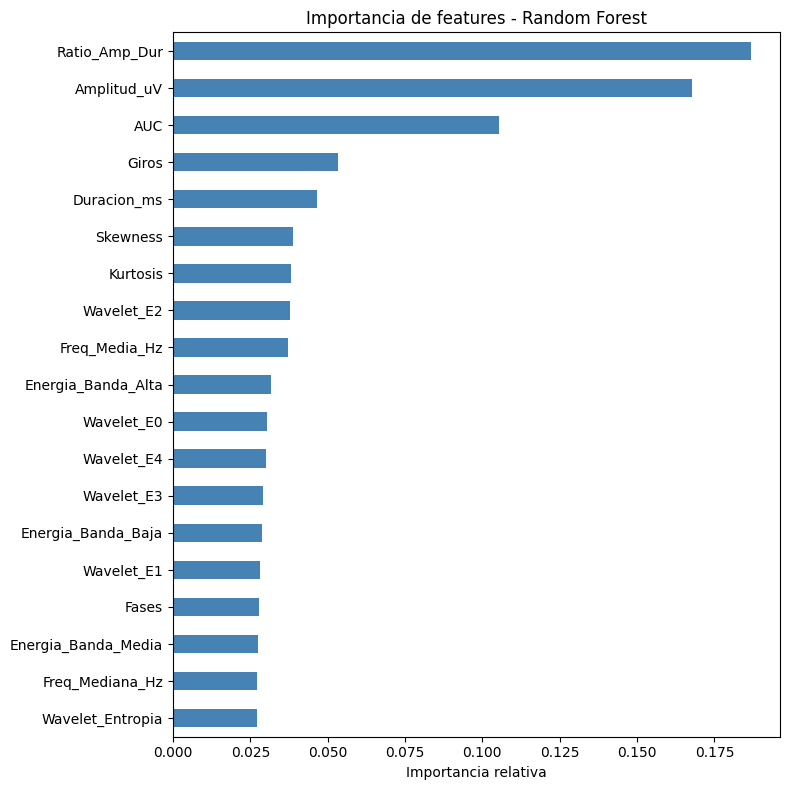


==== RESULTADOS - RED NEURONAL (MLP) ====
Accuracy: 0.808 | F1-macro: 0.797
              precision    recall  f1-score   support

    miopatia       0.63      0.63      0.63       631
  neuropatia       0.93      0.94      0.93       661
        sano       0.83      0.83      0.83      1379

    accuracy                           0.81      2671
   macro avg       0.80      0.80      0.80      2671
weighted avg       0.81      0.81      0.81      2671



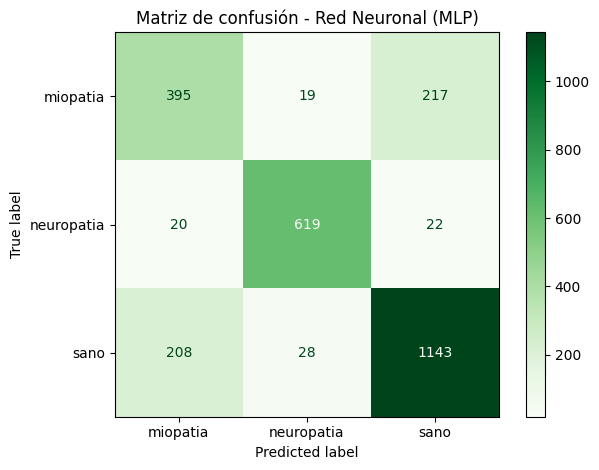


==== COMPARACIÓN DE MODELOS ====
               Modelo  Accuracy  F1-macro
0       Random Forest  0.808311  0.775804
1  Red Neuronal (MLP)  0.807563  0.796959


In [ ]:
"""### Segmentación de señales de deltoides

"""

all_muaps_healthy_delt = []
all_desv_std_healthy_delt = []
for i, signal in enumerate(all_pp_healthy_delt):
    muaps, _, _, desv_std = segmentar_muaps(signal, fs)
    all_muaps_healthy_delt.extend(muaps)
    all_desv_std_healthy_delt.extend([desv_std] * len(muaps))

print(f"Segmented {len(all_muaps_healthy_delt)} MUAPs from all healthy deltoid signals.")

all_muaps_myopathy_delt = []
all_desv_std_myopathy_delt = []
for i, signal in enumerate(all_pp_myopathy_delt):
    muaps, _, _, desv_std = segmentar_muaps(signal, fs)
    all_muaps_myopathy_delt.extend(muaps)
    all_desv_std_myopathy_delt.extend([desv_std] * len(muaps))

print(f"Segmented {len(all_muaps_myopathy_delt)} MUAPs from all myopathy deltoid signals.")

all_muaps_neuropathy_delt = []
all_desv_std_neuropathy_delt = []
for i, signal in enumerate(all_pp_neuropathy_delt):
    muaps, _, _, desv_std = segmentar_muaps(signal, fs)
    all_muaps_neuropathy_delt.extend(muaps)
    all_desv_std_neuropathy_delt.extend([desv_std] * len(muaps))

print(f"Segmented {len(all_muaps_neuropathy_delt)} MUAPs from all neuropathy deltoid signals.")

"""### Segmentación de señales de bíceps"""

all_muaps_healthy_biceps = []
all_desv_std_healthy_biceps = []
for i, signal in enumerate(all_pp_healthy_biceps):
    muaps, _, _, desv_std = segmentar_muaps(signal, fs)
    all_muaps_healthy_biceps.extend(muaps)
    all_desv_std_healthy_biceps.extend([desv_std] * len(muaps))

print(f"Segmented {len(all_muaps_healthy_biceps)} MUAPs from all healthy biceps signals.")

all_muaps_myopathy_biceps = []
all_desv_std_myopathy_biceps = []
for i, signal in enumerate(all_pp_myopathy_biceps):
    muaps, _, _, desv_std = segmentar_muaps(signal, fs)
    all_muaps_myopathy_biceps.extend(muaps)
    all_desv_std_myopathy_biceps.extend([desv_std] * len(muaps))

print(f"Segmented {len(all_muaps_myopathy_biceps)} MUAPs from all myopathy biceps signals.")

all_muaps_neuropathy_biceps = []
all_desv_std_neuropathy_biceps = []
for i, signal in enumerate(all_pp_neuropathy_biceps):
    muaps, _, _, desv_std = segmentar_muaps(signal, fs)
    all_muaps_neuropathy_biceps.extend(muaps)
    all_desv_std_neuropathy_biceps.extend([desv_std] * len(muaps))

print(f"Segmented {len(all_muaps_neuropathy_biceps)} MUAPs from all neuropathy biceps signals.")

"""### Extracción de características y tabla comparativa de señales de deltoides"""

df_healthy_delt = extraer_metricas_dataset(all_muaps_healthy_delt, fs, np.mean(all_desv_std_healthy_delt), musculo="deltoides", condicion="sano")
df_myopathy_delt = extraer_metricas_dataset(all_muaps_myopathy_delt, fs, np.mean(all_desv_std_myopathy_delt), musculo="deltoides", condicion="miopatia")
df_neuropathy_delt = extraer_metricas_dataset(all_muaps_neuropathy_delt, fs, np.mean(all_desv_std_neuropathy_delt), musculo="deltoides", condicion="neuropatia")


resumen_healthy_delt = df_healthy_delt.drop(columns=["Musculo", "Condicion"]).agg(["mean", "std"]).T
resumen_myopathy_delt = df_myopathy_delt.drop(columns=["Musculo", "Condicion"]).agg(["mean", "std"]).T
resumen_neuropathy_delt = df_neuropathy_delt.drop(columns=["Musculo", "Condicion"]).agg(["mean", "std"]).T


tabla_comparativa_all_delt = pd.DataFrame(
    {
        "Sujeto Sano (Media ± DE)": resumen_healthy_delt.apply(
            lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1
        ),
        "Miopatía (Media ± DE)": resumen_myopathy_delt.apply(
            lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1
        ),
        "Neuropatía (Media ± DE)": resumen_neuropathy_delt.apply(
            lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1
        ),
    }
)

print("\n==== TABLA DE CARACTERÍSTICAS EXTRAÍDAS PARA TODOS LOS SEÑALES DE DELTOIDES ====")
display(tabla_comparativa_all_delt)

"""### Extracción de características y tabla comparativa de señales de bíceps"""

df_healthy_biceps = extraer_metricas_dataset(all_muaps_healthy_biceps, fs, np.mean(all_desv_std_healthy_biceps), musculo="biceps", condicion="sano")
df_myopathy_biceps = extraer_metricas_dataset(all_muaps_myopathy_biceps, fs, np.mean(all_desv_std_myopathy_biceps), musculo="biceps", condicion="miopatia")
df_neuropathy_biceps = extraer_metricas_dataset(all_muaps_neuropathy_biceps, fs, np.mean(all_desv_std_neuropathy_biceps), musculo="biceps", condicion="neuropatia")


resumen_healthy_biceps = df_healthy_biceps.drop(columns=["Musculo", "Condicion"]).agg(["mean", "std"]).T
resumen_myopathy_biceps = df_myopathy_biceps.drop(columns=["Musculo", "Condicion"]).agg(["mean", "std"]).T
resumen_neuropathy_biceps = df_neuropathy_biceps.drop(columns=["Musculo", "Condicion"]).agg(["mean", "std"]).T


tabla_comparativa_all_biceps = pd.DataFrame(
    {
        "Sujeto Sano (Media ± DE)": resumen_healthy_biceps.apply(
            lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1
        ),
        "Miopatía (Media ± DE)": resumen_myopathy_biceps.apply(
            lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1
        ),
        "Neuropatía (Media ± DE)": resumen_neuropathy_biceps.apply(
            lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1
        ),
    }
)

print("\n==== TABLA DE CARACTERÍSTICAS EXTRAÍDAS PARA TODOS LOS SEÑALES DE BÍCEPS ====")
display(tabla_comparativa_all_biceps)
"""### Dataset consolidado para Machine Learning

Se combinan todas las señales segmentadas (ambos músculos, las tres condiciones)
en un único DataFrame. Cada fila es un MUAP individual con sus features y su
etiqueta de condición (sano / miopatía / neuropatía). Como la base de datos no
trae etiquetas a nivel de MUAP, se asume que todos los MUAPs segmentados de una
señal patológica pertenecen a esa patología (heredan la etiqueta del paciente).
Esta es una limitación metodológica que se debe aclarar en el informe.
"""

df_dataset_completo = pd.concat(
    [
        df_healthy_delt, df_myopathy_delt, df_neuropathy_delt,
        df_healthy_biceps, df_myopathy_biceps, df_neuropathy_biceps,
    ],
    ignore_index=True,
)

print(f"\nDataset consolidado: {df_dataset_completo.shape[0]} MUAPs, "
      f"{df_dataset_completo.shape[1]} columnas")
print(df_dataset_completo["Condicion"].value_counts())

# Columnas de features (todo menos las etiquetas)
columnas_features = [c for c in df_dataset_completo.columns if c not in ("Musculo", "Condicion")]

# Se descartan filas con NaN/Inf que puedan haber quedado de MUAPs mal segmentados
df_dataset_completo = df_dataset_completo.replace([np.inf, -np.inf], np.nan).dropna(
    subset=columnas_features
).reset_index(drop=True)

X = df_dataset_completo[columnas_features].values
y = df_dataset_completo["Condicion"].values
musculo_col = df_dataset_completo["Musculo"].values

"""### Estandarización y PCA (técnica novedosa: reducción de dimensionalidad)

Se estandarizan las features (media 0, desvío 1) porque están en escalas muy
distintas (µV, ms, energías relativas adimensionales, etc.) y se aplica PCA
para visualizar en 2D qué tan separables son las tres clases con el nuevo
conjunto ampliado de características.
"""

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

print(f"\nVarianza explicada por las 2 primeras componentes: "
      f"{pca.explained_variance_ratio_[0]*100:.1f}% + "
      f"{pca.explained_variance_ratio_[1]*100:.1f}% = "
      f"{pca.explained_variance_ratio_.sum()*100:.1f}%")

colores_condicion = {"sano": "blue", "miopatia": "red", "neuropatia": "green"}

plt.figure(figsize=(9, 7))
for condicion in ["sano", "miopatia", "neuropatia"]:
    mask = y == condicion
    plt.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        color=colores_condicion[condicion], alpha=0.4, s=15, label=condicion,
    )
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA del dataset de MUAPs (features ampliadas)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

"""### Separación entrenamiento / prueba

Se separa el dataset en 80% entrenamiento y 20% prueba, estratificando por
clase para mantener la proporción de sano/miopatía/neuropatía en ambos conjuntos.
"""

X_train, X_test, y_train, y_test = train_test_split(
    X_std, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nEntrenamiento: {X_train.shape[0]} MUAPs | Prueba: {X_test.shape[0]} MUAPs")

"""### Modelo 1: Random Forest (técnica clásica de Aprendizaje Automático)

Se elige Random Forest como primer modelo por ser robusto frente a features en
distintas escalas, no requerir demasiado ajuste de hiperparámetros y permitir
interpretar qué features aportan más a la clasificación (importancia de
variables), lo cual es útil para el análisis de resultados del informe.
"""

modelo_rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, random_state=42, class_weight="balanced"
)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average="macro")

print("\n==== RESULTADOS - RANDOM FOREST ====")
print(f"Accuracy: {acc_rf:.3f} | F1-macro: {f1_rf:.3f}")
print(classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap="Blues")
plt.title("Matriz de confusión - Random Forest")
plt.tight_layout()
plt.show()

# Importancia de features: ayuda a justificar en el informe qué features
# aportan más a distinguir sano/miopatía/neuropatía
importancias = pd.Series(modelo_rf.feature_importances_, index=columnas_features)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(8, 8))
importancias.plot(kind="barh", color="steelblue")
plt.title("Importancia de features - Random Forest")
plt.xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

"""### Modelo 2: Red Neuronal (MLP - Perceptrón Multicapa)

Como segunda técnica, distinta en naturaleza a un ensamble de árboles, se
entrena una Red Neuronal (MLP) sobre las mismas features estandarizadas. Al
ser una red densa simple es más rápida de entrenar que una CNN sobre la señal
cruda y permite comparar directamente "AA clásico" vs. "RN" sobre el mismo
conjunto de características ampliado con Wavelets.
"""

modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-3,
    max_iter=1000,
    random_state=42,
)
modelo_mlp.fit(X_train, y_train)
y_pred_mlp = modelo_mlp.predict(X_test)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
f1_mlp = f1_score(y_test, y_pred_mlp, average="macro")

print("\n==== RESULTADOS - RED NEURONAL (MLP) ====")
print(f"Accuracy: {acc_mlp:.3f} | F1-macro: {f1_mlp:.3f}")
print(classification_report(y_test, y_pred_mlp))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_mlp, cmap="Greens")
plt.title("Matriz de confusión - Red Neuronal (MLP)")
plt.tight_layout()
plt.show()

"""### Comparación final entre ambos modelos"""

tabla_comparativa_modelos = pd.DataFrame(
    {
        "Modelo": ["Random Forest", "Red Neuronal (MLP)"],
        "Accuracy": [acc_rf, acc_mlp],
        "F1-macro": [f1_rf, f1_mlp],
    }
)

print("\n==== COMPARACIÓN DE MODELOS ====")
print(tabla_comparativa_modelos)

### Tabla Comparativa Consolidada de Características (Deltoides y Bíceps)

In [ ]:
resumen_sano_total = df_dataset_completo[df_dataset_completo['Condicion'] == 'sano'].drop(columns=["Musculo", "Condicion"]).agg(["mean", "std"]).T
resumen_miopatia_total = df_dataset_completo[df_dataset_completo['Condicion'] == 'miopatia'].drop(columns=["Musculo", "Condicion"]).agg(["mean", "std"]).T
resumen_neuropatia_total = df_dataset_completo[df_dataset_completo['Condicion'] == 'neuropatia'].drop(columns=["Musculo", "Condicion"]).agg(["mean", "std"]).T

tabla_comparativa_consolidada = pd.DataFrame(
    {
        "Sujeto Sano (Media ± DE)": resumen_sano_total.apply(
            lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1
        ),
        "Miopatía (Media ± DE)": resumen_miopatia_total.apply(
            lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1
        ),
        "Neuropatía (Media ± DE)": resumen_neuropatia_total.apply(
            lambda r: f"{r['mean']:.3f} ± {r['std']:.3f}", axis=1
        ),
    }
)

print("\n==== TABLA DE CARACTERÍSTICAS EXTRAÍDAS PARA TODAS LAS SEÑALES (CONSOLIDADO) ====")
display(tabla_comparativa_consolidada)


==== TABLA DE CARACTERÍSTICAS EXTRAÍDAS PARA TODAS LAS SEÑALES (CONSOLIDADO) ====


,Sujeto Sano (Media ± DE),Miopatía (Media ± DE),Neuropatía (Media ± DE)
Amplitud_uV,1164.795 ± 724.491,1564.366 ± 1069.779,3698.624 ± 2011.411
Duracion_ms,12.151 ± 7.081,12.812 ± 8.126,11.998 ± 6.897
Fases,4.145 ± 2.192,4.569 ± 2.946,3.632 ± 1.863
Giros,3.693 ± 2.540,4.265 ± 3.564,3.231 ± 2.109
AUC,2.870 ± 2.581,4.106 ± 3.942,9.119 ± 7.463
Ratio_Amp_Dur,115.306 ± 75.181,133.086 ± 87.369,364.398 ± 214.665
Skewness,-0.495 ± 0.967,-0.427 ± 1.002,-0.137 ± 1.199
Kurtosis,0.703 ± 1.621,0.915 ± 1.967,0.876 ± 1.897
Freq_Media_Hz,220.062 ± 73.847,219.169 ± 96.706,196.498 ± 86.390
Freq_Mediana_Hz,181.214 ± 94.276,180.533 ± 106.825,158.116 ± 100.065
